# Imports

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

In [25]:
file_path_kw_all = '../Data/Intermediate/all_keywords_long.csv'
file_path_recession = '../Data/Intermediate/USREC_cleaned.csv'
file_path_gdp = '../Data/Intermediate/GDP_YoY_pct_cleaned.csv'
file_path_unemp_rate = '../Data/Intermediate/unemp_rate_cleaned.csv'
file_path_sahmcurrent = '../Data/Intermediate/SAHMCURRENT_cleaned.csv'

## Data preview

In [26]:
kwords_all = pd.read_csv(file_path_kw_all , parse_dates=["date"])
kwords_all

,date,keyword,category,search_interest
0,2004-01-01,0_percent_APR,Credit_and_debt,0
1,2004-02-01,0_percent_APR,Credit_and_debt,0
2,2004-03-01,0_percent_APR,Credit_and_debt,0
3,2004-04-01,0_percent_APR,Credit_and_debt,0
4,2004-05-01,0_percent_APR,Credit_and_debt,0
...,...,...,...,...
131731,2025-08-01,weekend_getaway,Travel,59
131732,2025-09-01,weekend_getaway,Travel,53
131733,2025-10-01,weekend_getaway,Travel,50
131734,2025-11-01,weekend_getaway,Travel,48


In [27]:
recession = pd.read_csv(file_path_recession, parse_dates=["observation_date"])
recession

,observation_date,USREC
0,2004-01-01,0
1,2004-02-01,0
2,2004-03-01,0
3,2004-04-01,0
4,2004-05-01,0
...,...,...
260,2025-09-01,0
261,2025-10-01,0
262,2025-11-01,0
263,2025-12-01,0


In [28]:
gdp = pd.read_csv(file_path_gdp, parse_dates=["date"])
gdp

,date,gdp_yoy_pct_change
0,2004-01-01,4.3
1,2004-02-01,4.3
2,2004-03-01,4.3
3,2004-04-01,4.2
4,2004-05-01,4.2
...,...,...
259,2025-08-01,2.3
260,2025-09-01,2.3
261,2025-10-01,2.2
262,2025-11-01,2.2


In [29]:
unemp_rate = pd.read_csv(file_path_unemp_rate, parse_dates=["date"])
unemp_rate

,date,UNRATE,unrate_mom_change,unrate_yoy_change
0,2004-01-01,5.7,0.0,-0.1
1,2004-02-01,5.6,-0.1,-0.3
2,2004-03-01,5.8,0.2,-0.1
3,2004-04-01,5.6,-0.2,-0.4
4,2004-05-01,5.6,0.0,-0.5
...,...,...,...,...
258,2025-07-01,4.3,0.2,0.1
259,2025-08-01,4.3,0.0,0.1
260,2025-09-01,4.4,0.1,0.3
261,2025-11-01,4.5,NaN,0.3


In [30]:
sahmcurrent = pd.read_csv(file_path_sahmcurrent, parse_dates=['observation_date'])
sahmcurrent

,observation_date,SAHMCURRENT
0,2004-01-01,-0.10
1,2004-02-01,-0.07
2,2004-03-01,0.03
3,2004-04-01,0.00
4,2004-05-01,0.00
...,...,...
260,2025-09-01,0.23
261,2025-10-01,0.25
262,2025-11-01,0.35
263,2025-12-01,0.35


# EDA

First, we start by understanding what our data distribution looks like. We can look at them as a whole and per category.

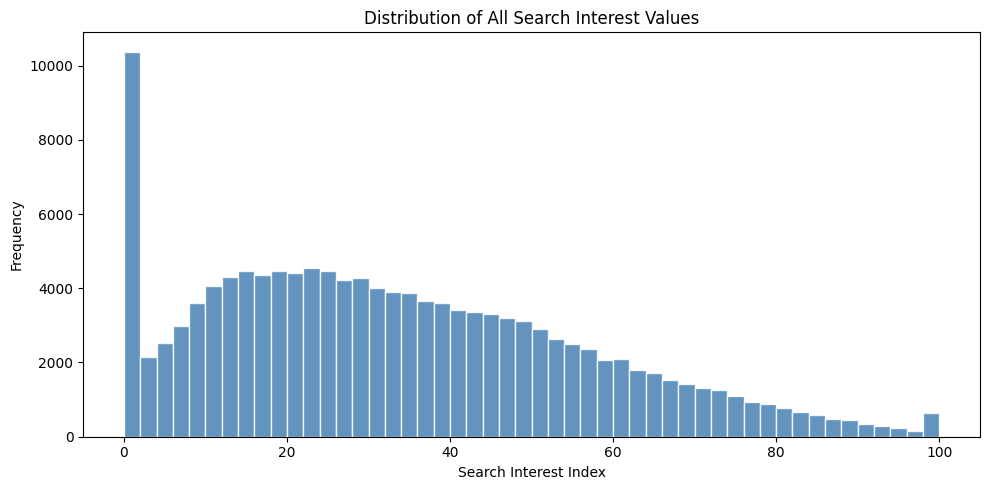

In [31]:
df = kwords_all
df['year'] = df['date'].dt.year

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['search_interest'].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('Distribution of All Search Interest Values')
ax.set_xlabel('Search Interest Index')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

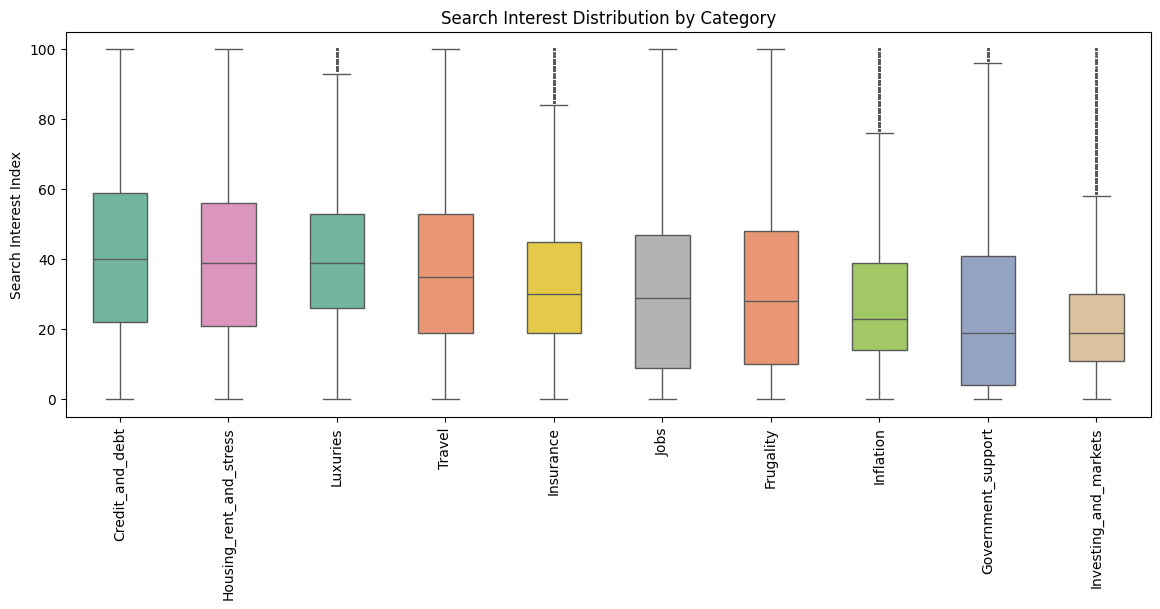

In [53]:
cat_order = df.groupby('category')['search_interest'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=df, x='category', y='search_interest', order=cat_order, hue='category', palette='Set2', ax=ax, fliersize=1, legend=False, width=0.5)
ax.set_title('Search Interest Distribution by Category')
ax.set_xlabel('')
ax.set_ylabel('Search Interest Index')
plt.setp(ax.get_xticklabels(), rotation=90, ha='center')
plt.show()

From these plots, we can see that the data is mostly right skewed with most keyword months at low values. Reflecting on this, it makes sense all of the values are based the keyword's highest search volume, for each keyword, there can only be about one month with 100, and it must have at least one month with the value of 100. We will keep this in mind but average distribution itself doesn't give us very valueable insight.

We can try to see the trends over time inspecting activity during and outside of recession periods. 

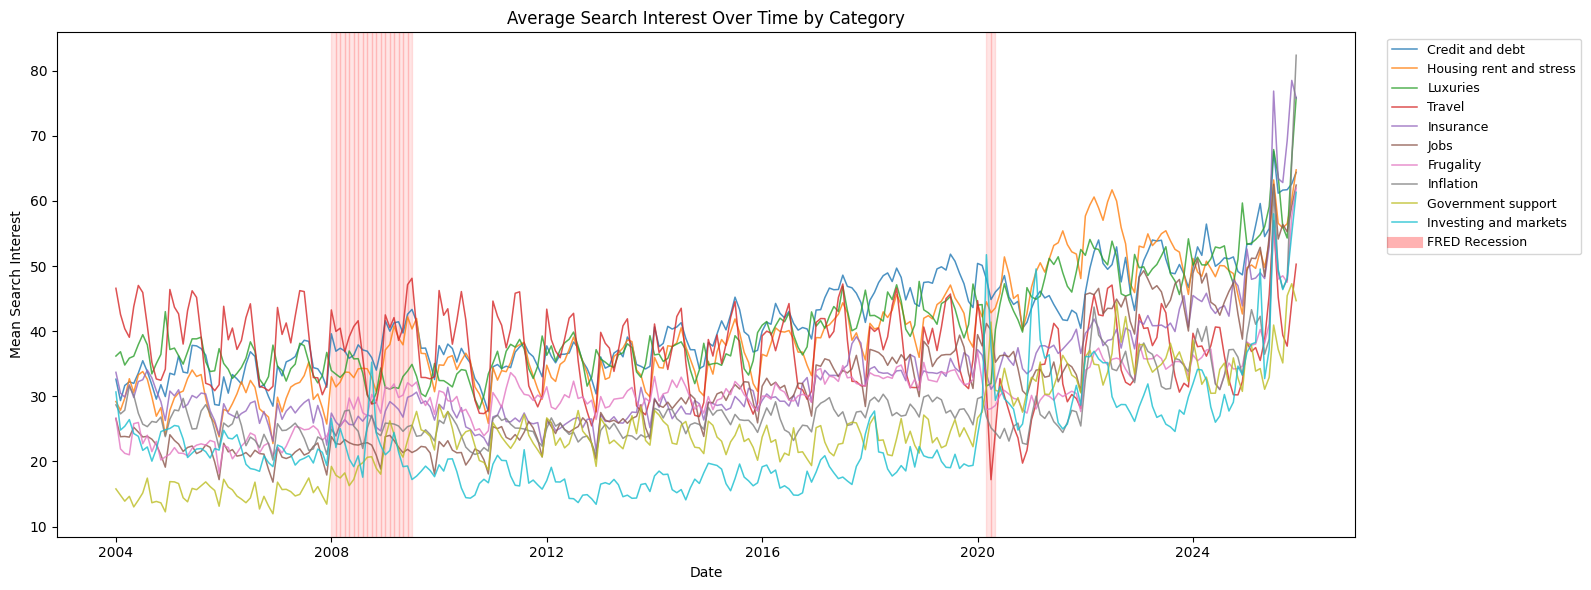

In [33]:
rec = recession.copy()
rec = rec.rename(columns={'observation_date': 'date'})

cat_monthly = df.groupby(['date', 'category'])['search_interest'].mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 6))
palette = sns.color_palette('tab10', n_colors=df['category'].nunique())

for i, cat in enumerate(cat_order):
    subset = cat_monthly[cat_monthly['category'] == cat]
    ax.plot(subset['date'], subset['search_interest'],
            label=cat.replace('_', ' '), color=palette[i], alpha=0.8, linewidth=1.1)

rec_months = rec[rec['USREC'] == 1]['date']
for d in rec_months:
    ax.axvspan(d, d + pd.DateOffset(months=1), alpha=0.10, color='red')
ax.plot([], [], color='red', alpha=0.3, linewidth=8, label='FRED Recession')

ax.set_title('Average Search Interest Over Time by Category')
ax.set_xlabel('Date')
ax.set_ylabel('Mean Search Interest')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

From this plot, we can see that there are some unusual spikes and drops such as categories like `Government support` and `Investing and markets` during the recession periods but compared to the rest of the trends, they almost blend into the annual cycle. On top of that, we can also observe that search prevalence values have generally increased toward more recent years.

To carry forward from this, we can try to compute a 12 month rolling z-score for each keyword so that we measure how far each month deviates from that keyword's recent average. This would  allow us to compare the values across different periods without working about searches increasing over the years. We could also try to observe a narrower time window to further breakdown what trend changes are happening. 

In [34]:
df_z = df.sort_values(['category', 'keyword', 'date']).copy()
grouped = df_z.groupby(['category', 'keyword'])['search_interest']
roll_mean = grouped.transform(lambda x: x.rolling(12, min_periods=6).mean())
roll_std  = grouped.transform(lambda x: x.rolling(12, min_periods=6).std()).clip(lower=0.1)
df_z['z_score'] = (df_z['search_interest'] - roll_mean) / roll_std
df_z = df_z.dropna(subset=['z_score'])

print(f'After detrending: {len(df_z):,} keyword-months')
print(f'Z-score mean: {df_z["z_score"].mean():.4f}, std: {df_z["z_score"].std():.2f}')

After detrending: 129,241 keyword-months
Z-score mean: 0.0865, std: 1.02


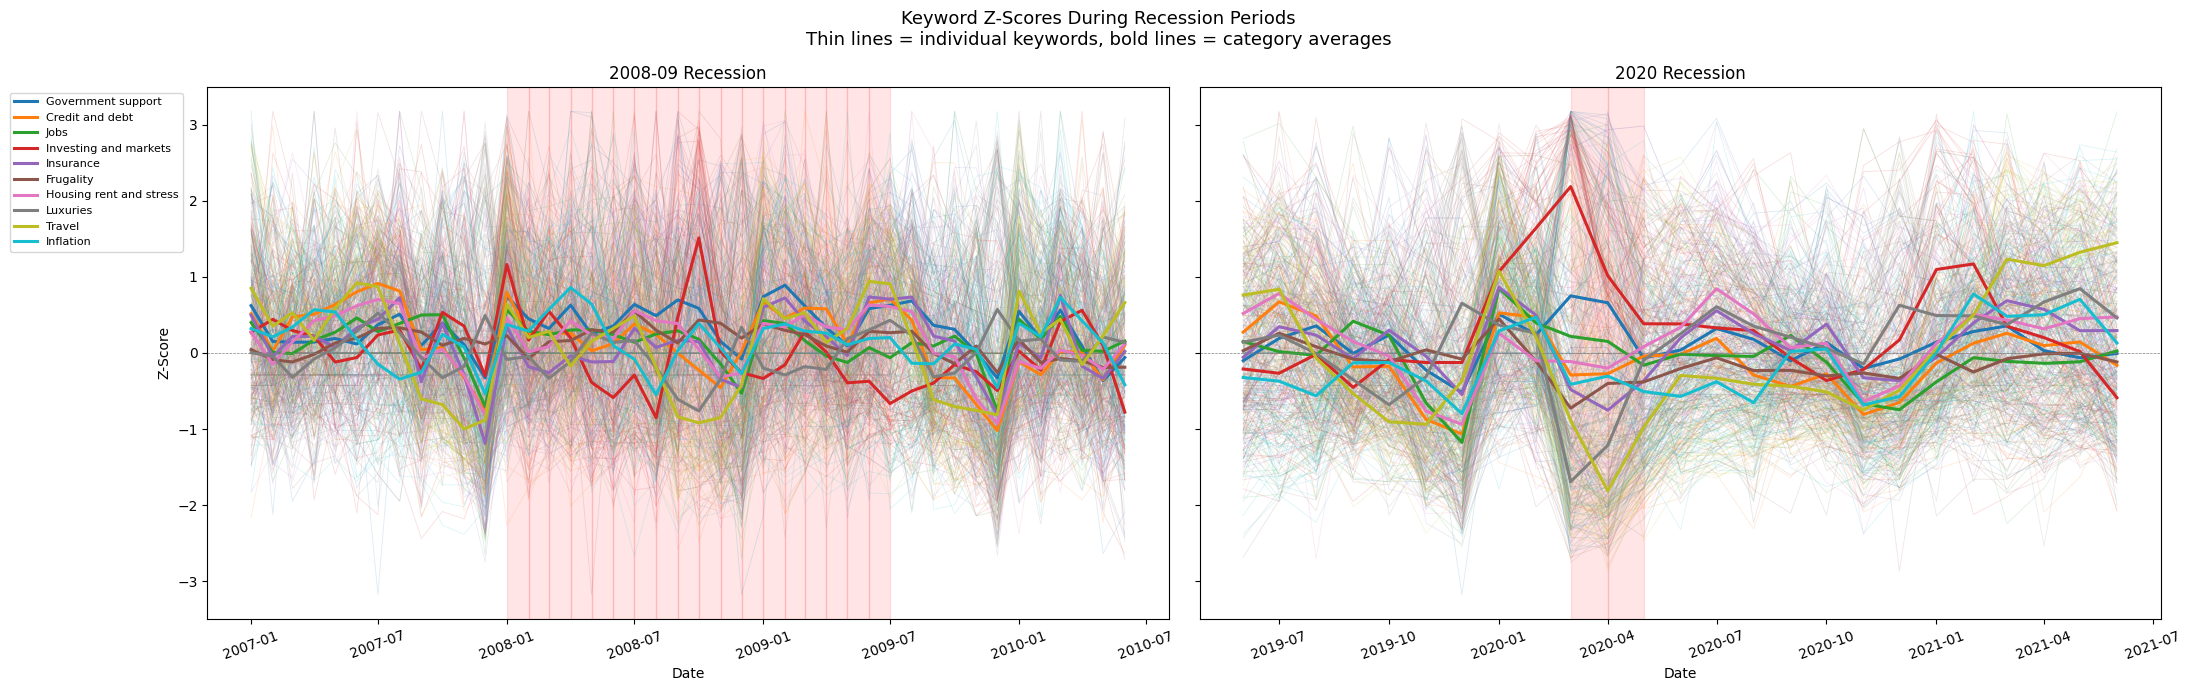

In [35]:
zoom_windows = {
    '2008-09 Recession': ('2007-01-01', '2010-06-01'),
    '2020 Recession':    ('2019-06-01', '2021-06-01')
}
show_cats = ['Government_support', 'Credit_and_debt', 'Jobs', 'Investing_and_markets',
             'Insurance', 'Frugality', 'Housing_rent_and_stress', 'Luxuries', 'Travel', 'Inflation']
cat_colors = dict(zip(show_cats, sns.color_palette('tab10', len(show_cats))))

fig, axes = plt.subplots(1, 2, figsize=(22, 7), sharey=True)

for ax, (title, (start, end)) in zip(axes, zoom_windows.items()):
    window_data = df_z[(df_z['date'] >= start) & (df_z['date'] <= end)]
    
    for cat in show_cats:
        cat_data = window_data[window_data['category'] == cat]
        for kw in cat_data['keyword'].unique():
            kw_data = cat_data[cat_data['keyword'] == kw]
            ax.plot(kw_data['date'], kw_data['z_score'], color=cat_colors[cat], alpha=0.15, linewidth=0.6)
    
    cat_means = window_data[window_data['category'].isin(show_cats)] \
        .groupby(['date', 'category'])['z_score'].mean().reset_index()
    for cat in show_cats:
        subset = cat_means[cat_means['category'] == cat]
        ax.plot(subset['date'], subset['z_score'], color=cat_colors[cat], linewidth=2.2, label=cat.replace('_', ' '))
    
    window_rec = rec[(rec['date'] >= start) & (rec['date'] <= end) & (rec['USREC'] == 1)]
    for d in window_rec['date']:
        ax.axvspan(d, d + pd.DateOffset(months=1), alpha=0.10, color='red')
    
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.tick_params(axis='x', rotation=20)

axes[0].set_ylabel('Z-Score')
axes[0].legend(fontsize=8, bbox_to_anchor=(-0.02, 1), loc='upper right')
fig.suptitle('Keyword Z-Scores During Recession Periods\nThin lines = individual keywords, bold lines = category averages', fontsize=13)
plt.tight_layout()
plt.show()

From these graphs, we can see that during the 2008 to 2009 recession, category level z-scores fluctuate but remain close to zero, which suggest a gradual and spread out response over 18 months. A category that stands out is `Investing and Markets` as it drops in the first half of 2008 then spikes in the second half, which lines up with the September 2008 financial crisis. Something worth noting is that we see most search categories dip sharply on Decembers, which reflect seasonal slowdown of search activity since our z-scores can't adjust for that. 

In the 2020 recession, the graph actually seems very different with a sharp increase for `Investing and Markets` and `Government support` while keywords in categories `Luxuries` and `Travel` dropped significantly with z-scores of nearly -2. In this graph, we also see the drop and lift of all categories between December and January in alignment with winter holidays. 

Now that we have a rough sense of how keyword search behavior shifts and how they look like during months of recession, we should look at a continuous economic indicator for a fuller picture. We can compute Pearson correlation coefficient between each keyword's detrended z-score and the unemployment rate. The $r$ value will range between $-1$ and $1$ which can give us the strength and direction of a linear relationship. 

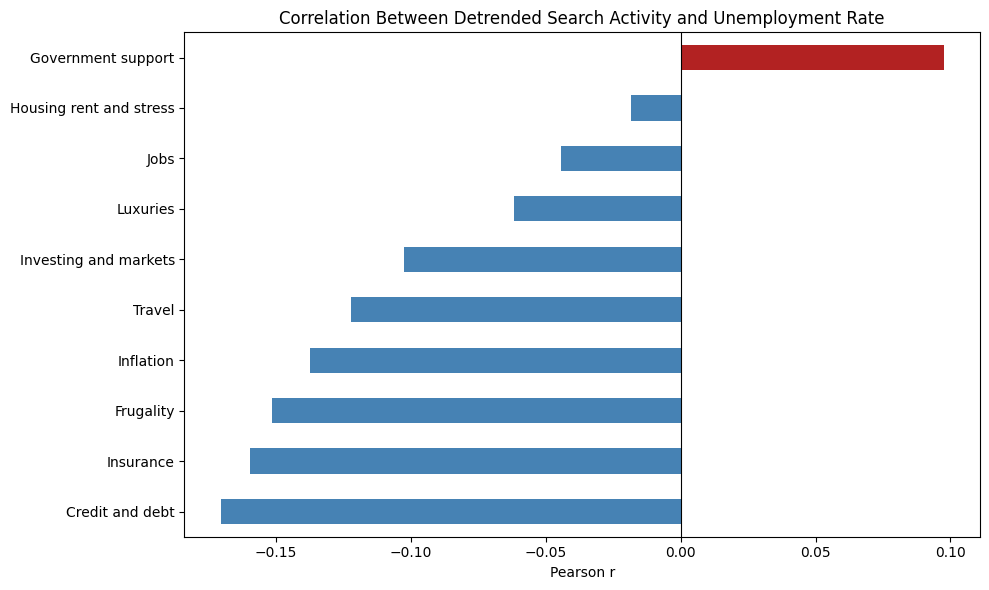

In [54]:
econ = unemp_rate[['date', 'UNRATE', 'unrate_yoy_change']].merge(
    rec[['date', 'USREC']], on='date', how='outer'
).sort_values('date')

cat_z_monthly = df_z.groupby(['date', 'category'])['z_score'].mean().unstack('category')
cat_z_monthly.columns = [f'zsearch_{c}' for c in cat_z_monthly.columns]
merged_z = econ.merge(cat_z_monthly, left_on='date', right_index=True, how='inner')

zsearch_cols = [c for c in merged_z.columns if c.startswith('zsearch_')]

corr_unemp = merged_z[zsearch_cols + ['UNRATE']].corr()['UNRATE'].drop('UNRATE').sort_values()
corr_unemp.index = [c.replace('zsearch_', '').replace('_', ' ') for c in corr_unemp.index]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['firebrick' if v > 0 else 'steelblue' for v in corr_unemp]
corr_unemp.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation Between Detrended Search Activity and Unemployment Rate')
ax.set_xlabel('Pearson r')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

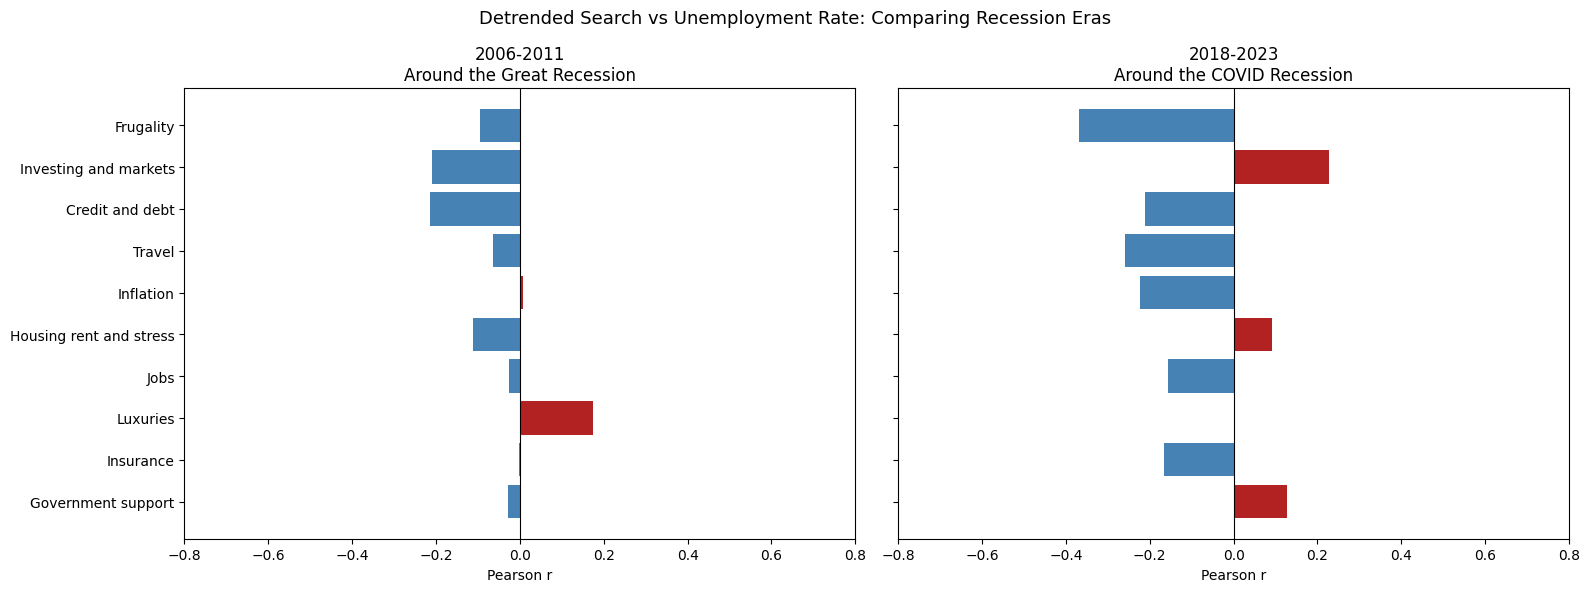

In [38]:
period_2008 = ('2006-01-01', '2011-12-01')
period_2020 = ('2018-01-01', '2023-12-01')

def corr_for_era(start, end):
    mask = (merged_z['date'] >= start) & (merged_z['date'] <= end)
    sub = merged_z.loc[mask]
    corrs = sub[zsearch_cols + ['UNRATE']].corr()['UNRATE'].drop('UNRATE').sort_values()
    corrs.index = [c.replace('zsearch_', '').replace('_', ' ') for c in corrs.index]
    return corrs

corr_2008 = corr_for_era(*period_2008)
corr_2020 = corr_for_era(*period_2020)

avg_abs = ((corr_2008.abs() + corr_2020.abs()) / 2).sort_values()
order = avg_abs.index

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

colors_2008 = ['firebrick' if v > 0 else 'steelblue' for v in corr_2008.loc[order]]
axes[0].barh(order, corr_2008.loc[order], color=colors_2008)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('2006-2011\nAround the Great Recession')
axes[0].set_xlabel('Pearson r')
axes[0].set_xlim(-0.8, 0.8)

colors_2020 = ['firebrick' if v > 0 else 'steelblue' for v in corr_2020.loc[order]]
axes[1].barh(order, corr_2020.loc[order], color=colors_2020)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('2018-2023\nAround the COVID Recession')
axes[1].set_xlabel('Pearson r')
axes[1].set_xlim(-0.8, 0.8)

fig.suptitle('Detrended Search vs Unemployment Rate: Comparing Recession Eras', fontsize=13)
plt.tight_layout()
plt.show()

In [52]:
kw_z_monthly = df_z.groupby(['date', 'category', 'keyword'])['z_score'].mean().reset_index()
kw_merged = kw_z_monthly.merge(econ[['date', 'UNRATE']].dropna(), on='date', how='inner')

def keyword_correlation(data, label):
    results = []
    for (cat, kw), grp in data.groupby(['category', 'keyword']):
        if len(grp) < 12:
            continue
        if grp['z_score'].std() < 0.01:
            continue
        r, p = stats.pearsonr(grp['z_score'], grp['UNRATE'])
        results.append({'category': cat, 'keyword': kw, 'pearson_r': round(r, 4), 'p_value': round(p, 4), 'n_months': len(grp)})
    result_df = pd.DataFrame(results).sort_values('pearson_r', ascending=False)
    
    print(f'---\n{label}')
    print(f'Ten highest positive correlations with unemployment:')
    print(result_df.head(10)[['category', 'keyword', 'pearson_r', 'p_value']].to_string(index=False))
    print(f'\nTen lowest negative correlations with unemployment:')
    print(result_df.tail(10)[['category', 'keyword', 'pearson_r', 'p_value']].to_string(index=False))
    return result_df

# full period
corrs_all = keyword_correlation(kw_merged, '2004-2025')

# 2008 recession period
period_2008 = ('2006-01-01', '2011-12-01')
mask_08 = (kw_merged['date'] >= period_2008[0]) & (kw_merged['date'] <= period_2008[1])
corrs_2008 = keyword_correlation(kw_merged[mask_08], '2006-2011')

# 2020 recession period
period_2020 = ('2018-01-01', '2023-12-01')
mask_20 = (kw_merged['date'] >= period_2020[0]) & (kw_merged['date'] <= period_2020[1])
corrs_2020 = keyword_correlation(kw_merged[mask_20], '2018-2023')

---
2004-2025
Ten highest positive correlations with unemployment:
               category                keyword  pearson_r  p_value
     Government_support            EBT_balance     0.4458      0.0
        Credit_and_debt           credit_karma     0.4370      0.0
     Government_support   pandemic_relief_fund     0.3836      0.0
                   Jobs              Glassdoor     0.3726      0.0
                   Jobs                 Fiverr     0.3648      0.0
               Luxuries      painting_for_sale     0.3206      0.0
Housing_rent_and_stress        rent_assistance     0.2996      0.0
     Government_support unemployment_extension     0.2955      0.0
              Frugality             promo_code     0.2685      0.0
              Frugality            coupon_apps     0.2550      0.0

Ten lowest negative correlations with unemployment:
               category               keyword  pearson_r  p_value
                 Travel        travel_booking    -0.2796      0.0
           

From this computation, we can see that overall, keywords in the `Government support`, `Credit and debt`, and `Jobs`categories such as `EBT balance`, `credit karma`, `Glassdoor` and `Fiverr` have have weak to moderate correlation with unemployement rates. Whereas `balance transfer` and `debt consolidation` were negatively correlated with unemployment in every period. This could suggest that while people are employed, people are making more financial management searches. 

Between 2006 and 2011, the top positive correlations include `coupon apps` and `Glassdoor` with $r=0.69$ and $r=0.68$ respectively, which are moderately strong relations. However, we can't directly attribute these upward trends to the recession because Glassdoor and Groupon (a major coupon platform) were began their operations around 2007 and 2008, which can explain the relative spike in search interest z value. Another surprising finding is the `Louis Vuitton` and `Hermes bag` showed positive correlations during unemployement rises too. On the negative side, `foreclosure` ($r=-0.55$) and `recession` ($r=-0.50$) z-scores suggest that people searched them heavily in early 2008, before unemployment peaked, and search interest normalized even as unemploymen stayed high. 

In the 2018 to 2023 period, government support keywords like `rental_assistance_program` ($r=0.67$), `unemployment_extension` ($r=0.64$), and `stimulus_check` ($r=0.52$) rose with unemployment which is something we'd expect. Travel keywords like `Caribbean_cruise` ($r=-0.50$) and `cruise_deals` ($r=-0.46$) feel. This could suggest that economic downturn was reflected by search behavior, but it could also be a reflection of global travel bans and pandemic mitigation strategies. 